# Material coefficient block encoding

Test `material_coefficient_block_encoding` using Qiskit circuits, statevectors,
and operator comparisons, as in the other circuit testing notebooks.

The function uses `midsize_basic_circuits.integer_comparator_gate` and arbitrary rotations. For clean work
and post-selection qubits, the selected block must equal $D/\alpha$.
All work ancillas must return to zero, including on the rejected branch.
Blocks are zero-based, half-open `(start, stop, value)` intervals; omitted
entries are zero. These tests compare complex amplitudes, not just probabilities.

The local comparator requires `n + 1` clean work ancillas: one interval flag and an `n`-qubit threshold register.


In [1]:
from pathlib import Path
import sys

# Allow running from either the repository root or Elementary_circuits.
repo_root = Path.cwd()
if repo_root.name == 'Elementary_circuits':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator, Statevector
import numpy as np

from Elementary_circuits import material_coefficient_circuits

encode = material_coefficient_circuits.material_coefficient_block_encoding
np.set_printoptions(precision=5, suppress=True)
ATOL = 1e-12

## Test helpers

Build the expected diagonal independently using NumPy. Reconstruct the selected
matrix one basis-state column at a time to avoid constructing a large full unitary.
Qubit positions are resolved from the circuit, so the checks also support reordered
registers. Workspace cleanup is checked over the entire output state.

In [2]:
# Create the circuit and apply the material coefficient block encoding
def make_circuit(n, blocks, alpha=None, useElementaryGates=True):
    x = QuantumRegister(n, 'x')
    ps = QuantumRegister(1, 'ps')
    ancillas = QuantumRegister(n + 1, 'ancilla') # interval flag plus n threshold qubits
    qc = QuantumCircuit(x, ps, ancillas)
    assert encode(qc, x, ps, ancillas, blocks, alpha, useElementaryGates=useElementaryGates) is qc # apply the material coefficient block encoding to the circuit
    return qc, x, ps, ancillas

# classically compute the expected diagonal of the piecewise-constant matrix
def expected_diagonal(n, blocks, alpha=None):
    diagonal = np.zeros(2**n, dtype=complex)
    for start, stop, value in blocks:
        diagonal[start:stop] = value
    scale = alpha if alpha is not None else (np.max(np.abs(diagonal)) or 1.0)
    return diagonal / scale

# returns a list of the statevector indices corresponding the computational basis states of the main register x
def selected_indices(qc, x):
    return np.array([
        sum(((value >> bit) & 1) << qc.find_bit(qubit).index
            for bit, qubit in enumerate(x))
        for value in range(2**len(x))
    ])

def assert_clean_workspace(state, qc, ancillas):
    mask = sum(1 << qc.find_bit(qubit).index for qubit in ancillas)
    dirty = (np.arange(len(state.data)) & mask) != 0
    np.testing.assert_allclose(state.data[dirty], 0, atol=ATOL, rtol=0) # ensure all ancilla qubits are returned to the |0> state

# return a matrix of the output states after evolving through the circuit
def check_basis_states(qc, x, ancillas, diagonal):
    indices = selected_indices(qc, x) # all possible input states
    selected = np.zeros((len(indices), len(indices)), dtype=complex) # matrix to store the output states corresponding to the input basis states
    for column, input_index in enumerate(indices):
        initial = np.zeros(2**qc.num_qubits, dtype=complex)
        initial[input_index] = 1
        state = Statevector(initial).evolve(qc) # evolve the circuit to create the output state
        selected[:, column] = state.data[indices] # store the post-selected section of the output state as the corresponding column in the selected matrix
        assert_clean_workspace(state, qc, ancillas)
    np.testing.assert_allclose(selected, np.diag(diagonal), atol=ATOL, rtol=0)
    return selected

## Arbitrary boundaries example: elements 1–7 = 6.4, elements 8–21 = 7.7

Five address qubits give 32 diagonal entries. The remaining 11 entries are zero.
Test every input address, including both sides of each interval boundary, with
explicit normalization `alpha=7.7`.

Expected diagonal: [0.83117 0.83117 0.83117 0.83117 0.83117 0.83117 0.83117 1.      1.
 1.      1.      1.      1.      1.      1.      1.      1.      1.
 1.      1.      1.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.     ]
Encoded diagonal:  [0.83117 0.83117 0.83117 0.83117 0.83117 0.83117 0.83117 1.      1.
 1.      1.      1.      1.      1.      1.      1.      1.      1.
 1.      1.      1.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.     ]
Maximum matrix error: 1.9895196601282805e-13
All 32 basis states and work-ancilla cleanup passed.
Circuit gate counts: {'geq_7': 4, 'geq_0': 2, 'cry': 2, 'geq_21': 2, 'ry': 1}


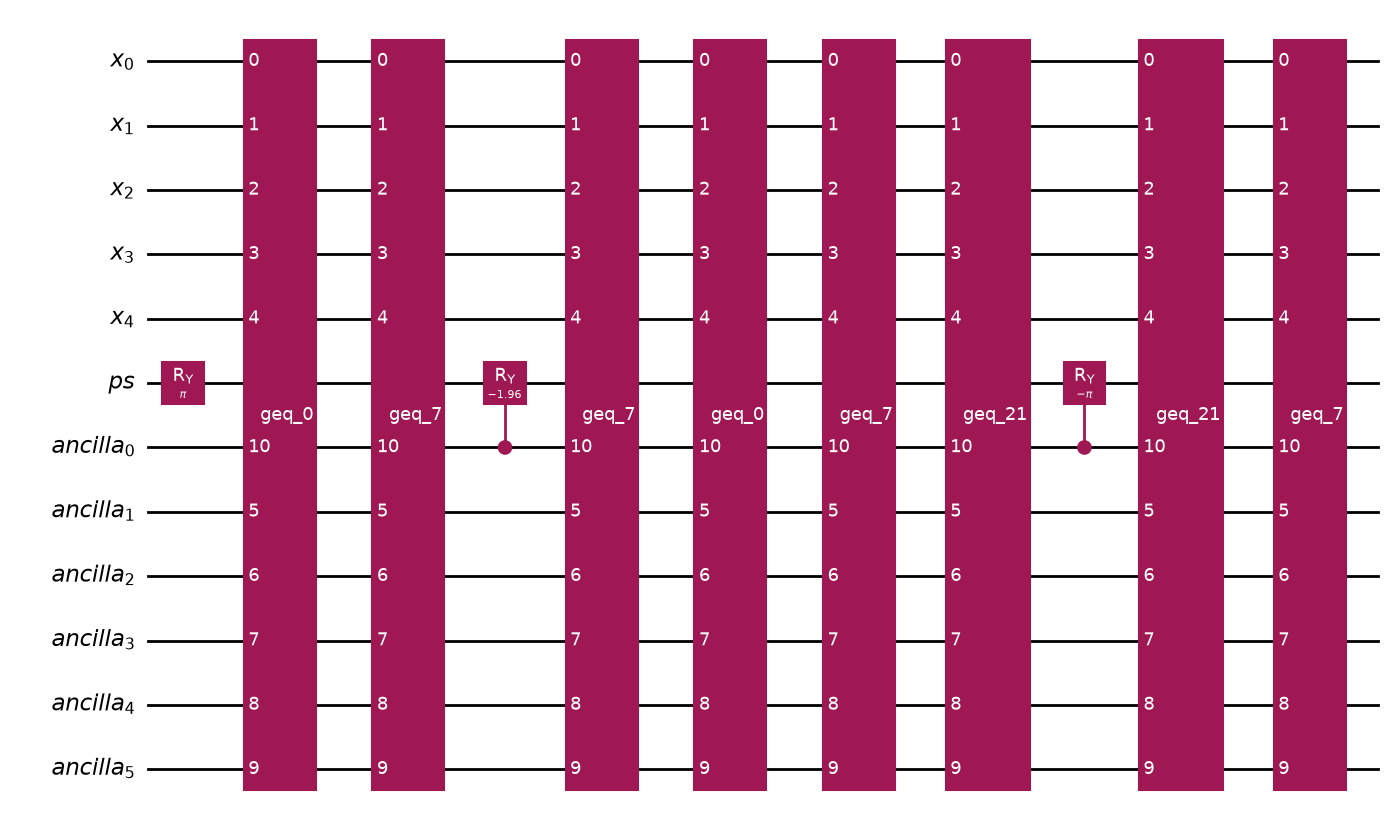

In [3]:
blocks = [(0, 7, 6.4), (7, 21, 7.7)]
qc, x, ps, ancillas = make_circuit(5, blocks, alpha=7.7, useElementaryGates=False)
diagonal = expected_diagonal(5, blocks, alpha=7.7)
selected = check_basis_states(qc, x, ancillas, diagonal)

print('Expected diagonal:', diagonal.real)
print('Encoded diagonal: ', np.diag(selected).real)
print('Maximum matrix error:', np.max(np.abs(selected - np.diag(diagonal))))
print('All 32 basis states and work-ancilla cleanup passed.')
print('Circuit gate counts:', dict(qc.count_ops()))
# Display the circuit graphically (requires pylatexenc).
qc.draw('mpl')

## Full operator test: signed and complex coefficients

For a small circuit, extract the zero-ancilla block of the full unitary and
compare it directly with the target. This catches sign and relative-phase errors.
Also verify unitarity. Here automatic normalization is 2.

In [4]:
complex_blocks = [(0, 1, -2), (1, 2, 1j), (2, 4, 1 - 1j)]
small_qc, small_x, small_ps, small_ancillas = make_circuit(2, complex_blocks)
unitary = Operator(small_qc).data
indices = selected_indices(small_qc, small_x)
encoded_block = unitary[np.ix_(indices, indices)]
complex_diagonal = expected_diagonal(2, complex_blocks)
np.testing.assert_allclose(encoded_block, np.diag(complex_diagonal), atol=ATOL, rtol=0)
np.testing.assert_allclose(unitary.conj().T @ unitary, np.eye(len(unitary)), atol=ATOL, rtol=0)
check_basis_states(small_qc, small_x, small_ancillas, complex_diagonal)
print('Target matrix:\n', np.diag(complex_diagonal))
print('Encoded matrix:\n', encoded_block)
print('Complex block, full-unitary, and workspace checks passed.')

Target matrix:
 [[-1. +0.j   0. +0.j   0. +0.j   0. +0.j ]
 [ 0. +0.j   0. +0.5j  0. +0.j   0. +0.j ]
 [ 0. +0.j   0. +0.j   0.5-0.5j  0. +0.j ]
 [ 0. +0.j   0. +0.j   0. +0.j   0.5-0.5j]]
Encoded matrix:
 [[-1. +0.j   0. +0.j   0. -0.j   0. +0.j ]
 [ 0. +0.j  -0. +0.5j  0. +0.j   0. -0.j ]
 [-0. +0.j   0. +0.j   0.5-0.5j  0. +0.j ]
 [ 0. +0.j   0. +0.j   0. +0.j   0.5-0.5j]]
Complex block, full-unitary, and workspace checks passed.


## Superposition and post-selection probability

For a reproducible complex input $|\psi\rangle$, the unnormalized selected state
must be $D|\psi\rangle/\alpha$, and the success probability must be its squared
norm. Retaining unnormalized amplitudes is essential for checking the scale.

In [5]:
rng = np.random.default_rng(42)
psi = rng.normal(size=4) + 1j * rng.normal(size=4)
psi /= np.linalg.norm(psi)
initial = np.zeros(2**small_qc.num_qubits, dtype=complex)
initial[indices] = psi
state = Statevector(initial).evolve(small_qc)
expected = complex_diagonal * psi
actual = state.data[indices]
np.testing.assert_allclose(actual, expected, atol=ATOL, rtol=0)
assert_clean_workspace(state, small_qc, small_ancillas)
ps_mask = 1 << small_qc.find_bit(small_ps[0]).index
success = (np.arange(len(state.data)) & ps_mask) == 0
success_probability = np.sum(np.abs(state.data[success])**2)
np.testing.assert_allclose(success_probability, np.vdot(expected, expected).real, atol=ATOL, rtol=0)
np.testing.assert_allclose(actual / np.linalg.norm(actual), expected / np.linalg.norm(expected), atol=ATOL, rtol=0)
print('Superposition amplitudes and normalized selected state passed.')
print('Post-selection probability:', success_probability)

Superposition amplitudes and normalized selected state passed.
Post-selection probability: 0.6523374721587675


## Boundary cases and register layouts

Cover a one-qubit address, full-domain intervals, single-entry blocks, gaps,
unsorted blocks, empty/all-zero matrices, and explicit normalization larger than
the largest coefficient. Also test noncontiguous address qubits, integer qubit
arguments, and an extra clean work qubit.

In [6]:
cases = [
    ('one address qubit', 1, [(0, 1, -2), (1, 2, 1j)], None),
    ('full domain', 3, [(0, 8, 3)], None),
    ('gaps and unsorted blocks', 3, [(7, 8, -2j), (1, 3, -1)], None),
    ('empty matrix', 2, [], None),
    ('explicit zeros', 2, [(0, 4, 0)], None),
    ('larger normalization', 2, [(0, 2, 2), (2, 4, -1)], 5),
]
for name, n, test_blocks, alpha in cases:
    test_qc, test_x, test_ps, test_ancillas = make_circuit(n, test_blocks, alpha)
    check_basis_states(test_qc, test_x, test_ancillas, expected_diagonal(n, test_blocks, alpha))
    print(name + ': passed')

layout_qc = QuantumCircuit(7)
layout_blocks = [(0, 1, 1j), (1, 3, -2)]
encode(layout_qc, [4, 1], [3], [0, 5, 2, 6], layout_blocks)
check_basis_states(layout_qc, [layout_qc.qubits[i] for i in [4, 1]],
                   [layout_qc.qubits[i] for i in [0, 5, 2, 6]],
                   expected_diagonal(2, layout_blocks))
print('Reordered integer qubits and extra workspace: passed')

one address qubit: passed
full domain: passed
gaps and unsorted blocks: passed
empty matrix: passed
explicit zeros: passed
larger normalization: passed
Reordered integer qubits and extra workspace: passed


## Invalid inputs

Invalid block bounds, overlaps, nonfinite values, invalid normalization, and
incorrect qubit allocations must raise `ValueError` before adding any gates.

In [7]:
invalid_cases = [
    ('overlap', {'blocks': [(0, 3, 1), (2, 4, 2)]}),
    ('negative bound', {'blocks': [(-1, 2, 1)]}),
    ('out-of-range bound', {'blocks': [(0, 5, 1)]}),
    ('empty interval', {'blocks': [(2, 2, 1)]}),
    ('reversed interval', {'blocks': [(3, 1, 1)]}),
    ('noninteger bound', {'blocks': [(0, 1.5, 1)]}),
    ('NaN coefficient', {'blocks': [(0, 1, np.nan)]}),
    ('infinite coefficient', {'blocks': [(0, 1, np.inf)]}),
    ('alpha too small', {'alpha': 0.5}),
    ('zero alpha', {'alpha': 0}),
    ('negative alpha', {'alpha': -1}),
    ('NaN alpha', {'alpha': np.nan}),
    ('infinite alpha', {'alpha': np.inf}),
    ('empty address', {'x': []}),
    ('missing post-selection qubit', {'ps': []}),
    ('too few ancillas', {'ancillas': [3, 4]}),
    ('aliased qubits', {'ps': [0]}),
    ('invalid qubit index', {'x': [0, 6]}),
]
# Check the reason as well as the exception type, so unrelated validation
# failures cannot make these tests pass accidentally.
expected_errors = {
    'overlap': 'Blocks must not overlap',
    **dict.fromkeys(
        ['negative bound', 'out-of-range bound', 'empty interval',
         'reversed interval', 'noninteger bound'], 'Block bounds must be integers'),
    **dict.fromkeys(['NaN coefficient', 'infinite coefficient'],
                    'Block values must be finite'),
    **dict.fromkeys(['alpha too small', 'zero alpha', 'negative alpha',
                     'NaN alpha', 'infinite alpha'], 'alpha must be finite'),
    **dict.fromkeys(['empty address', 'missing post-selection qubit',
                     'too few ancillas'], 'Require nonempty x'),
    'aliased qubits': 'must contain distinct qubits',
    'invalid qubit index': 'Qubit index is outside qc',
}
for name, overrides in invalid_cases:
    invalid_qc = QuantumCircuit(6)
    arguments = dict(x=[0, 1], ps=[2], ancillas=[3, 4, 5], blocks=[(0, 4, 1)])
    arguments.update(overrides)
    try:
        encode(invalid_qc, **arguments)
    except ValueError as error:
        assert expected_errors[name] in str(error), f"{name}: unexpected error: {error}"
        assert len(invalid_qc.data) == 0, name + ': circuit was modified'
    else:
        raise AssertionError(name + ': invalid input accepted')
print(f'All {len(invalid_cases)} invalid-input checks passed.')
print('All material coefficient circuit tests passed.')

All 18 invalid-input checks passed.
All material coefficient circuit tests passed.


## Elementary-gate scaling under fixed-domain refinement

Keep the original physical coefficient profile on a domain of length $L=1$:
6.4 on $[0,7L/32)$, 7.7 on $[7L/32,21L/32)$, and zero on
$[21L/32,L)$. At refinement level $r$, $N=32\,2^r$ cells have width
$h=L/N$. Multiply every interval endpoint by $2^r$, leaving coefficients
and $\alpha=7.7$ unchanged. Thus each diagonal entry becomes two identical
entries at the next level ($D_{r+1}=D_r\otimes I_2$).

Count the complete encoding, including workspace uncomputation, after translation
to the fixed elementary basis `u` (arbitrary one-qubit unitary) and `cx` (CNOT).
Use optimization level 0 and no hardware connectivity constraints, so these are
construction costs, without routing or rotation-approximation costs. This is not
a Clifford+T precision-dependent count or a lower bound on the optimal encoding.
Only circuits and interval descriptions are built; no large dense matrices or
statevectors are needed. The number of material regions stays fixed.


In [8]:
from qiskit import transpile
import matplotlib.pyplot as plt

# Independent of variables overwritten by the earlier boundary/invalid-input tests.
scaling_base_n = 5
scaling_base_blocks = [(0, 7, 6.4), (7, 21, 7.7)]
scaling_alpha = 7.7
scaling_domain_length = 1.0
scaling_levels = range(11)  # N = 32 through 32768; increase for further refinement.
scaling_basis = ['u', 'cx']
scaling_results = []

for level in scaling_levels:
    refinement = 2**level
    n_address = scaling_base_n + level
    n_cells = 2**n_address
    cell_width = scaling_domain_length / n_cells
    refined_blocks = [(start * refinement, stop * refinement, value)
                      for start, stop, value in scaling_base_blocks]

    # Physical interfaces and material values must stay fixed as h halves.
    for (start, stop, value), (base_start, base_stop, base_value) in zip(
            refined_blocks, scaling_base_blocks):
        np.testing.assert_allclose(
            np.array([start, stop]) * cell_width,
            np.array([base_start, base_stop]) * scaling_domain_length / 32,
            rtol=0, atol=ATOL)
        assert value == base_value
    if scaling_results:
        assert n_cells == 2 * scaling_results[-1]['N']
        assert cell_width == scaling_results[-1]['h'] / 2

    refinement_qc, _, _, _ = make_circuit(
        n_address, refined_blocks, alpha=scaling_alpha, useElementaryGates=True)
    elementary_qc = transpile(
        refinement_qc, basis_gates=scaling_basis,
        optimization_level=0, seed_transpiler=42)
    counts = elementary_qc.count_ops()
    assert set(counts).issubset(scaling_basis), counts
    assert all(len(instruction.qubits) <= 2 for instruction in elementary_qc.data)
    scaling_results.append({
        'level': level, 'N': n_cells, 'h': cell_width,
        'address_qubits': n_address, 'total_qubits': elementary_qc.num_qubits,
        'one_qubit': counts.get('u', 0), 'cx': counts.get('cx', 0),
        'gates': sum(counts.values()), 'depth': elementary_qc.depth(),
    })

print(f"{'level':>5} {'N':>8} {'h':>12} {'addr':>5} {'qubits':>6} "
      f"{'1q':>9} {'CX':>9} {'total':>10} {'depth':>9}")
for row in scaling_results:
    print(f"{row['level']:5d} {row['N']:8d} {row['h']:12.5g} "
          f"{row['address_qubits']:5d} {row['total_qubits']:6d} "
          f"{row['one_qubit']:9d} {row['cx']:9d} "
          f"{row['gates']:10d} {row['depth']:9d}")


level        N            h  addr qubits        1q        CX      total     depth
    0       32      0.03125     5     12      4159      2326       6485      3967
    1       64     0.015625     6     14      6151      3562       9713      5980
    2      128    0.0078125     7     16      8575      5086      13661      8481
    3      256    0.0039062     8     18     11431      6898      18329     11447
    4      512    0.0019531     9     20     14719      8998      23717     14904
    5     1024   0.00097656    10     22     18439     11386      29825     18841
    6     2048   0.00048828    11     24     22591     14062      36653     23258
    7     4096   0.00024414    12     26     27175     17026      44201     28155
    8     8192   0.00012207    13     28     32191     20278      52469     33532
    9    16384   6.1035e-05    14     30     37639     23818      61457     39389
   10    32768   3.0518e-05    15     32     43519     27646      71165     45726


Degree 1 fit in n = log2(N): coefficients [  6468. -31255.]; max relative residual = 8.327e-01
Degree 2 fit in n = log2(N): coefficients [ 360. -732. 1145.]; max relative residual = 1.311e-15
Additional gates per halving of h: [3228 3948 4668 5388 6108 6828 7548 8268 8988 9708]
Second differences: [720 720 720 720 720 720 720 720 720]
Constant first differences indicate log(N) growth; constant nonzero second differences indicate (log(N))^2 growth for this construction. Finite-range fits alone do not establish an asymptotic bound.


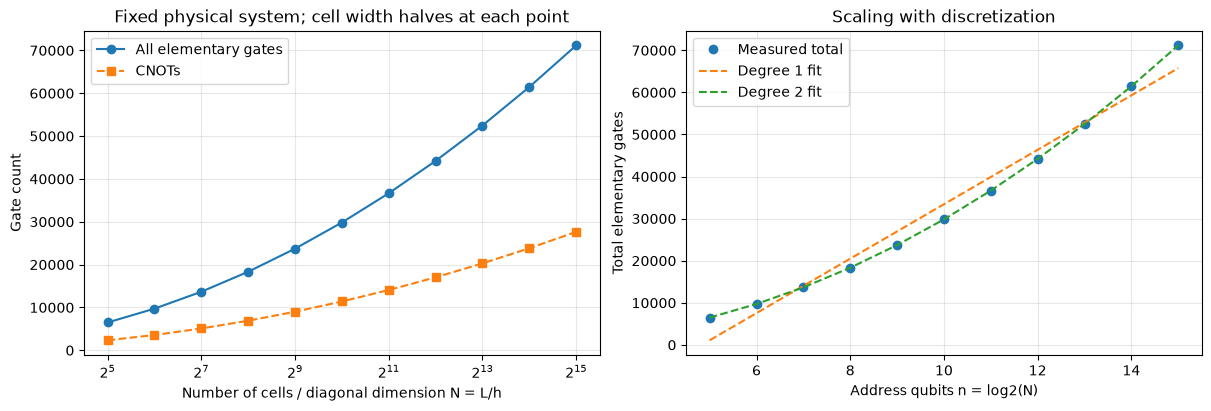

In [9]:
# Compare growth in log2(N) against quadratic growth in log2(N).
scaling_N = np.array([row['N'] for row in scaling_results])
scaling_n = np.array([row['address_qubits'] for row in scaling_results])
scaling_gates = np.array([row['gates'] for row in scaling_results])
scaling_cx = np.array([row['cx'] for row in scaling_results])
assert len(scaling_results) >= 4, 'Use at least four refinement levels for fitting.'

scaling_fits = {}
for degree in (1, 2):
    coefficients = np.polyfit(scaling_n, scaling_gates, degree)
    predicted = np.polyval(coefficients, scaling_n)
    relative_error = np.max(np.abs(predicted - scaling_gates) / scaling_gates)
    scaling_fits[degree] = (coefficients, predicted, relative_error)
    print(f'Degree {degree} fit in n = log2(N): coefficients {coefficients}; '
          f'max relative residual = {relative_error:.3e}')
print('Additional gates per halving of h:', np.diff(scaling_gates))
print('Second differences:', np.diff(scaling_gates, n=2))
print('Constant first differences indicate log(N) growth; constant nonzero '
      'second differences indicate (log(N))^2 growth for this construction. '
      'Finite-range fits alone do not establish an asymptotic bound.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(scaling_N, scaling_gates, 'o-', label='All elementary gates')
axes[0].plot(scaling_N, scaling_cx, 's--', label='CNOTs')
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('Number of cells / diagonal dimension N = L/h')
axes[0].set_ylabel('Gate count')
axes[0].set_title('Fixed physical system; cell width halves at each point')
axes[1].plot(scaling_n, scaling_gates, 'o', label='Measured total')
for degree, (_, predicted, _) in scaling_fits.items():
    axes[1].plot(scaling_n, predicted, '--', label=f'Degree {degree} fit')
axes[1].set_xlabel('Address qubits n = log2(N)')
axes[1].set_ylabel('Total elementary gates')
axes[1].set_title('Scaling with discretization')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.show()


### Interpretation of the measured scaling

With the current implementation and Qiskit 1.3.0, the default sweep gives
$G(N)=360(\log_2 N)^2-732\log_2 N+1145$ exactly at the sampled sizes:
6,485 gates at $N=32$ and 71,165 at $N=32768$. The constant second difference
of 720 matches quadratic growth in address qubits. The comparator's increment
and uncomputation use a sequence of increasingly wide controlled gates, each
decomposed into a linear-size Toffoli ladder, explaining the
$O((\log N)^2)=O((\log(L/h))^2)$ cost for this fixed number of regions.
These counts describe the current comparator construction and chosen basis;
changes to the implementation or compilation settings can change the counts.


## Elementary-gate scaling with the number of material regions

Hold the domain length $L=1$, matrix dimension $N=32$, cell width $h=L/N$,
and normalization $\alpha=7.7$ fixed. Sweep the number of contiguous regions
$R=1,2,4,8,16,32$, partitioning the entire domain into equal-width regions.
Alternate coefficients 6.4 and 7.7 so adjacent intervals are genuinely different
material regions, rather than artificial subdivisions of one constant material.
Here $R$ counts spatial regions, not distinct coefficient values. Unlike the
mesh-refinement study, this deliberately changes the physical material layout.

Use the same `u`/`cx` elementary basis, optimization level 0, and unrestricted
connectivity. Counts include the full encoding and workspace uncomputation;
arbitrary single-qubit rotations count as one gate. The sweep constructs circuits
without simulating their statevectors or allocating dense matrices.


In [10]:
from qiskit import transpile
import matplotlib.pyplot as plt

region_n_address = 5  # Fixed across the sweep; increase to support more regions.
region_N = 2**region_n_address
region_L = 1.0
region_h = region_L / region_N
region_alpha = 7.7
region_values = (6.4, 7.7)
region_counts = [2**k for k in range(region_n_address + 1)]
region_basis = ['u', 'cx']
region_results = []

for n_regions in region_counts:
    assert 1 <= n_regions <= region_N and region_N % n_regions == 0
    cells_per_region = region_N // n_regions
    region_blocks = [
        (j * cells_per_region, (j + 1) * cells_per_region,
         region_values[j % len(region_values)])
        for j in range(n_regions)
    ]
    # Cover exactly the same grid with R nonempty, distinct adjacent regions.
    assert len(region_blocks) == n_regions
    assert region_blocks[0][0] == 0 and region_blocks[-1][1] == region_N
    assert all(start < stop for start, stop, _ in region_blocks)
    assert all(left[1] == right[0] and left[2] != right[2]
               for left, right in zip(region_blocks, region_blocks[1:]))
    np.testing.assert_allclose(n_regions * cells_per_region * region_h, region_L)

    region_qc, _, _, _ = make_circuit(
        region_n_address, region_blocks, alpha=region_alpha,
        useElementaryGates=True)
    region_elementary_qc = transpile(
        region_qc, basis_gates=region_basis,
        optimization_level=0, seed_transpiler=42)
    region_ops = region_elementary_qc.count_ops()
    assert set(region_ops).issubset(region_basis), region_ops
    assert all(len(instruction.qubits) <= 2
               for instruction in region_elementary_qc.data)
    assert region_elementary_qc.num_qubits == 2 * region_n_address + 2
    region_results.append({
        'regions': n_regions, 'N': region_N, 'h': region_h,
        'cells_per_region': cells_per_region,
        'total_qubits': region_elementary_qc.num_qubits,
        'one_qubit': region_ops.get('u', 0), 'cx': region_ops.get('cx', 0),
        'gates': sum(region_ops.values()), 'depth': region_elementary_qc.depth(),
    })

print(f'Fixed domain L={region_L}, N={region_N}, h={region_h}, alpha={region_alpha}')
print(f"{'regions':>7} {'cells/region':>12} {'qubits':>6} "
      f"{'1q':>9} {'CX':>9} {'total':>10} {'depth':>9}")
for row in region_results:
    print(f"{row['regions']:7d} {row['cells_per_region']:12d} "
          f"{row['total_qubits']:6d} {row['one_qubit']:9d} "
          f"{row['cx']:9d} {row['gates']:10d} {row['depth']:9d}")


Fixed domain L=1.0, N=32, h=0.03125, alpha=7.7
regions cells/region qubits        1q        CX      total     depth
      1           32     12         5         2          7         6
      2           16     12      2759      1552       4311      2639
      4            8     12      8275      4652      12927      7910
      8            4     12     19323     10852      30175     18485
     16            2     12     41451     23252      64703     39606
     32            1     12     85771     48052     133823     81846


Linear fit: G(R) = 4316.83 R -4335.69
R^2 = 0.9999997884; max absolute residual = 30.5501 gates
Additional gates per added region between samples: [4304. 4308. 4312. 4316. 4320.]
Expected construction scaling: O(R) at fixed N, or O(R (log2 N)^2) when both parameters vary. Boundary preparation can cause small deviations from an exact affine fit.


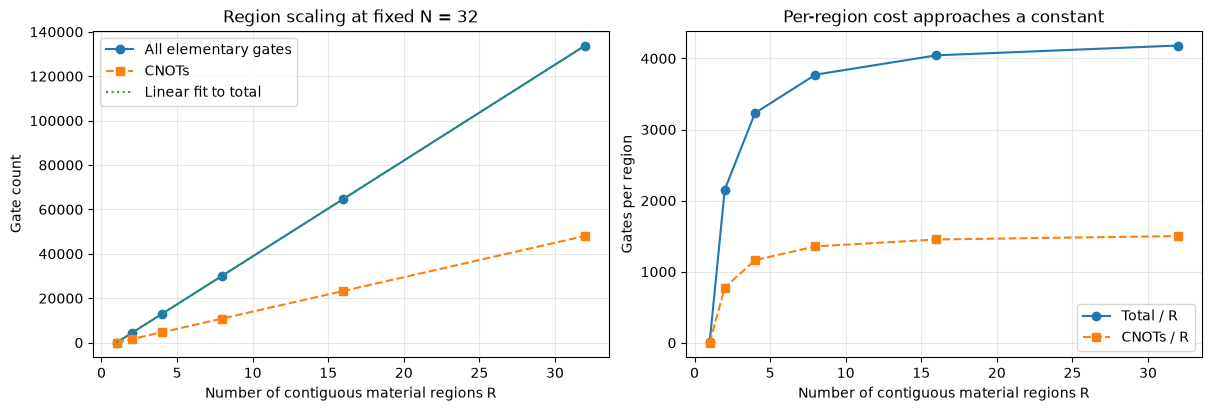

In [11]:
region_R = np.array([row['regions'] for row in region_results])
region_G = np.array([row['gates'] for row in region_results])
region_CX = np.array([row['cx'] for row in region_results])
assert len(region_R) >= 3, 'Use at least three region counts for fitting.'
region_fit = np.polyfit(region_R, region_G, 1)
region_prediction = np.polyval(region_fit, region_R)
region_residual = region_G - region_prediction
region_r_squared = 1 - np.sum(region_residual**2) / np.sum((region_G - region_G.mean())**2)
print(f'Linear fit: G(R) = {region_fit[0]:.6g} R {region_fit[1]:+.6g}')
print(f'R^2 = {region_r_squared:.10f}; '
      f'max absolute residual = {np.max(np.abs(region_residual)):.6g} gates')
print('Additional gates per added region between samples:',
      np.diff(region_G) / np.diff(region_R))
print('Expected construction scaling: O(R) at fixed N, or O(R (log2 N)^2) '
      'when both parameters vary. Boundary preparation can cause small '
      'deviations from an exact affine fit.')

region_fig, region_axes = plt.subplots(
    1, 2, figsize=(12, 4), constrained_layout=True)
region_axes[0].plot(region_R, region_G, 'o-', label='All elementary gates')
region_axes[0].plot(region_R, region_CX, 's--', label='CNOTs')
region_axes[0].plot(region_R, region_prediction, ':', label='Linear fit to total')
region_axes[0].set_ylabel('Gate count')
region_axes[0].set_title(f'Region scaling at fixed N = {region_N}')
region_axes[1].plot(region_R, region_G / region_R, 'o-', label='Total / R')
region_axes[1].plot(region_R, region_CX / region_R, 's--', label='CNOTs / R')
region_axes[1].set_ylabel('Gates per region')
region_axes[1].set_title('Per-region cost approaches a constant')
for ax in region_axes:
    ax.set_xlabel('Number of contiguous material regions R')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.show()


### Interpreting region-count scaling

Each nonzero region contributes at most four comparisons and one controlled
rotation, so the construction scales as $O(R(\log_2 N)^2)$ and hence $O(R)$
at fixed matrix dimension. Two domain endpoints use trivial comparisons;
in particular, the $R=1$ full-domain case requires no nontrivial comparator.
This gives a fixed boundary saving, so gate count per region need not be constant
for small $R$. Threshold preparation also depends on the binary digits of each
interface index and can produce small departures from an exact straight line.
The fit measures this particular family and implementation, not an optimal
encoding bound. At fixed $N$, the number of nonempty regions is limited to $N$.
